# HW4: Palmer Penguins — Summary Statistics & Plots

## Keith Bui - 806755932

### Setup

- Use only `pandas`, `matplotlib`, and `seaborn`.
- Do your work in the cells provided; you may add extra cells.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# (Optional) nicer display for DataFrames
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)


In [2]:
### Load the dataset
penguins = pd.read_csv("penguins.csv")

# Standardize column names (snake_case)
penguins.columns = [c.strip().lower().replace(' ', '_') for c in penguins.columns]

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### Part 1) Data Vitals

Answer the following questions.

Your answer to each question must include some code that produces the result. You can, but you do not have to use a complete sentence to answer each question. Add cells as needed.

- a. What is the shape of the data?
- b. What are the Column names and data types of each column?
- c. How many values in each column are missing?
- d. How many penguins are there of each species? How many male and female penguins are there?

In [3]:
# Your code here
print(f"a. The shape of the penguins dataset is {penguins.shape}.")
print(f"b. The column names in the dataset are: {list(penguins.columns)}.")
print(f"The data types of each column are:\n{penguins.dtypes}")
print(f"c.The number of missing values in each column is:\n{penguins.isnull().sum()}")

a. The shape of the penguins dataset is (344, 8).
b. The column names in the dataset are: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year'].
The data types of each column are:
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
year                   int64
dtype: object
c.The number of missing values in each column is:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


In [4]:
print(f"d. The number of penguins in each species is: \n{penguins['species'].value_counts()}")
print(f"The number of penguins in each sex is: \n{penguins['sex'].value_counts()}")

d. The number of penguins in each species is: 
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
The number of penguins in each sex is: 
sex
male      168
female    165
Name: count, dtype: int64


### Part 2) Handle missing data

- a. Create a copy `penguins_clean` that **drops** rows with missing values in
   `['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','sex']`.  
- b. Report the new shape of `penguins_clean`.


In [5]:
# Your code here
penguins_clean = penguins.dropna()
print(f"The new shape of the dataset after dropping missing values is: {penguins_clean.shape}.")

The new shape of the dataset after dropping missing values is: (333, 8).


### Part 3) Numeric summary statistics

- a. Compute the following **for each numeric column**: count, mean, std, min, 25%, 50%, 75%, max (hint: `.describe()`)
- b. Compute the mean and std for each numeric column for each `species`

In [6]:
# Your code here
print(penguins_clean.describe())
print(penguins_clean.groupby("species").mean(numeric_only=True))
print(penguins_clean.groupby("species").std(numeric_only=True))


       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g      year
count         333.000        333.000            333.000      333.000   333.000
mean           43.993         17.165            200.967     4207.057  2008.042
std             5.469          1.969             14.016      805.216     0.813
min            32.100         13.100            172.000     2700.000  2007.000
25%            39.500         15.600            190.000     3550.000  2007.000
50%            44.500         17.300            197.000     4050.000  2008.000
75%            48.600         18.700            213.000     4775.000  2009.000
max            59.600         21.500            231.000     6300.000  2009.000
           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
species                                                                    
Adelie             38.824         18.347            190.103     3706.164   
Chinstrap          48.834         18.421            195.824  

### Part 4) Two-way grouped summaries

a) For each **(species, sex)** combination, compute the **mean** and **count** of:
- `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`.

b) Which (species, sex) has the **largest average body_mass_g**? Show the row.



In [7]:
# Your code here
print(penguins_clean.groupby(["species", "sex"])[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]].mean())
print(penguins_clean.groupby(["species", "sex"])[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]].count())
print(penguins_clean.groupby(["species", "sex"])["body_mass_g"].mean().sort_values(ascending=False).idxmax())

                  bill_length_mm  bill_depth_mm  flipper_length_mm  \
species   sex                                                        
Adelie    female          37.258         17.622            187.795   
          male            40.390         19.073            192.411   
Chinstrap female          46.574         17.588            191.735   
          male            51.094         19.253            199.912   
Gentoo    female          45.564         14.238            212.707   
          male            49.474         15.718            221.541   

                  body_mass_g  
species   sex                  
Adelie    female     3368.836  
          male       4043.493  
Chinstrap female     3527.206  
          male       3938.971  
Gentoo    female     4679.741  
          male       5484.836  
                  bill_length_mm  bill_depth_mm  flipper_length_mm  \
species   sex                                                        
Adelie    female              73           

### Part 5) Correlations

- a. Compute the **correlation matrix** among numeric columns.  
- b. Compute the correlation matrix **within each species** (hint: groupby).  
- c. Find an example of Simpson's Paradox in the data. https://en.wikipedia.org/wiki/Simpson%27s_paradox  
        - An example Simpson's Paradox would be a pair of variables that have a positive correlation within subgroups, but when all the groups are combined, there is negative correlation (or vice-versa). 

In [8]:
# Your code here
corr_matrix = penguins_clean.corr(numeric_only=True)
print(corr_matrix)
species_corr = penguins_clean.groupby("species").corr(numeric_only=True)
print(species_corr)


                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm              1.000         -0.229              0.653   
bill_depth_mm              -0.229          1.000             -0.578   
flipper_length_mm           0.653         -0.578              1.000   
body_mass_g                 0.589         -0.472              0.873   
year                        0.033         -0.048              0.151   

                   body_mass_g   year  
bill_length_mm           0.589  0.033  
bill_depth_mm           -0.472 -0.048  
flipper_length_mm        0.873  0.151  
body_mass_g              1.000  0.022  
year                     0.022  1.000  
                             bill_length_mm  bill_depth_mm  flipper_length_mm  \
species                                                                         
Adelie    bill_length_mm              1.000          0.386              0.332   
          bill_depth_mm               0.386          1.000              0.311   
         

One example of Simpson's Paradox in the data can be found in the relationship between bill_length_mm and bill_depth_mm. When we look at the overall correlation between these two variables, we get a negative value of -0.229, however, when we look at the correlation within each species, we see that the correlations are positive (i.e. 0.386 for Adelie, 0.654 for Chinstrap, and 0.654 for Gentoo). This is an example of Simpson's Paradox because when all the groups are combined, there is a negative correlation, but when we group by species, there are positive correlations.

## Plots

- Each figure must have a **title**, **axis labels**, and a **legend** (when appropriate).
- Use readable tick labels and sensible limits.
- Be sure each graphic is displayed.

### Part 6) Histograms of body mass by species

Create **separate** histograms of `body_mass_g` for each species (three panels).
    
- Use the same binning across panels so comparisons are fair.  
- Label axes clearly


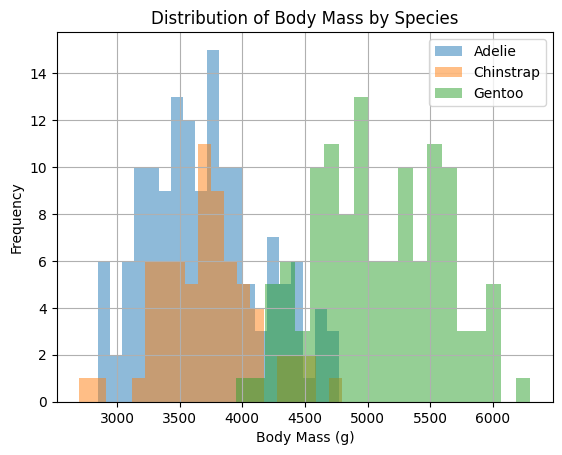

In [9]:
df_species = penguins_clean.groupby('species')['body_mass_g']
df_species.hist(bins=20, alpha=0.5, legend=True)
plt.xlabel('Body Mass (g)')
plt.ylabel('Frequency')
plt.title('Distribution of Body Mass by Species')
plt.show()

### Part 7) Boxplots of flipper length

Make a **single figure** with boxplots of `flipper_length_mm` by **species**.  

Briefly compare the medians and spreads in 2–3 sentences in a markdown cell.

Text(0.5, 1.0, 'Boxplot of Flipper Length by Species')

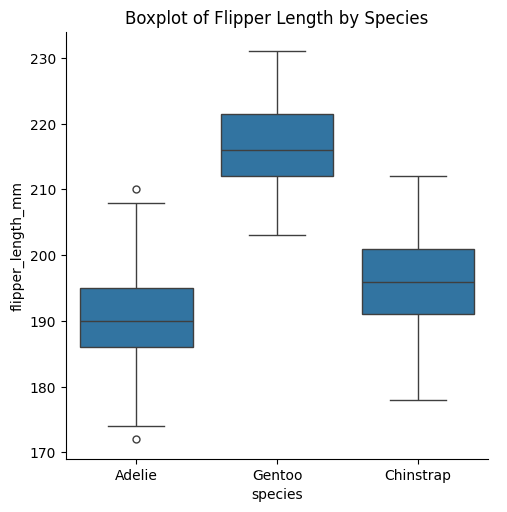

In [10]:
sns.catplot(data=penguins_clean, x="species", y="flipper_length_mm", kind="box")
plt.title("Boxplot of Flipper Length by Species")

After looking at the boxplots of flipper_length_mm by species we can see that the Gentoo species has the highest average flipper length with a median of around 215 mm. The Chinstrap species comes in second with a median of around 197 mm, and the Adelie species has the lowest average flipper_length_mm with a median of about 190 mm. Looking at the spreads of the individual boxplots, they all seem relatively equal with spreads ranging from 30-40 mm, however, one noticable observation can be seen with the Adelie species where there are two outliers. 

### Part 8) Scatter: bill length vs bill depth

- Make a scatter plot of **bill_length_mm** (x) vs **bill_depth_mm** (y), colored by species.
- Add a simple **linear fit line** per species
- Include a legend 

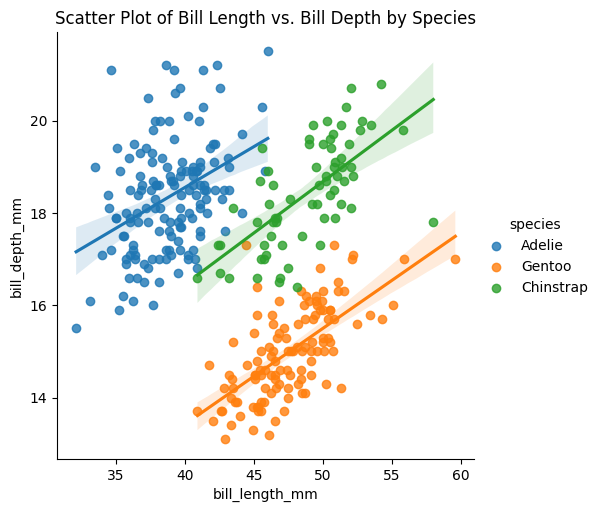

In [11]:
sns.lmplot(data=penguins_clean, x="bill_length_mm", y="bill_depth_mm", hue="species")
plt.title("Scatter Plot of Bill Length vs. Bill Depth by Species")
plt.show()

### Part 9) Stacked bars: sex proportions by species

Compute counts of `sex` within each `species`, convert to **proportions**, and make a **stacked bar chart**.  

- Bars should be species on the x‑axis with male/female proportions stacked to 1.0. 

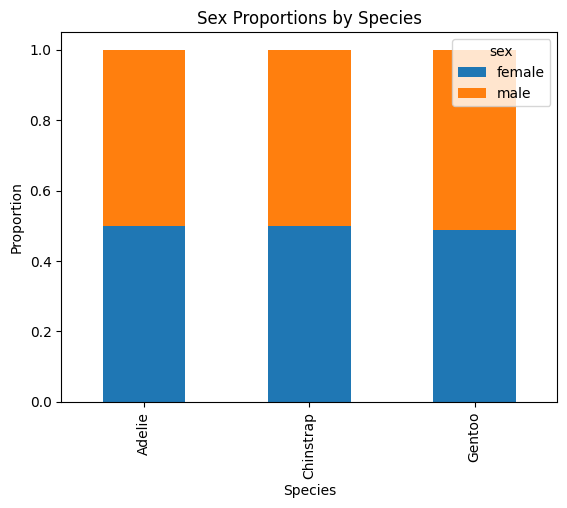

In [12]:
pd.crosstab(penguins_clean.species, penguins_clean.sex, normalize=0).plot(kind="bar", stacked=True)
plt.title("Sex Proportions by Species")
plt.xlabel("Species")
plt.ylabel("Proportion")
plt.show()